In [1]:
!pip install -q imbalanced-learn
!pip install -q deap
!pip install -q xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.5 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms
import random
import time
import warnings

In [3]:
# Suppress warnings
warnings.filterwarnings("ignore")

In [4]:
# Load dataset
df = pd.read_csv('/content/drive/MyDrive/IoT Network Intrusion Dataset.csv')
print("✅ Dataset Loaded")

# Shape and structure
print(f"🔹 Shape: {df.shape}")
print("🔹 First few rows:")
display(df.head())

✅ Dataset Loaded
🔹 Shape: (625783, 86)
🔹 First few rows:


,Flow_ID,Src_IP,Src_Port,Dst_IP,Dst_Port,Protocol,Timestamp,Flow_Duration,Tot_Fwd_Pkts,Tot_Bwd_Pkts,...,Active_Std,Active_Max,Active_Min,Idle_Mean,Idle_Std,Idle_Max,Idle_Min,Label,Cat,Sub_Cat
0,192.168.0.13-192.168.0.16-10000-10101-17,192.168.0.13,10000,192.168.0.16,10101,17,25/07/2019 03:25:53 AM,75,1,1,...,0.0,0.0,0.0,75.0,0.000000,75.0,75.0,Anomaly,Mirai,Mirai-Ackflooding
1,192.168.0.13-222.160.179.132-554-2179-6,222.160.179.132,2179,192.168.0.13,554,6,26/05/2019 10:11:06 PM,5310,1,2,...,0.0,0.0,0.0,2655.0,2261.327486,4254.0,1056.0,Anomaly,DoS,DoS-Synflooding
2,192.168.0.13-192.168.0.16-9020-52727-6,192.168.0.16,52727,192.168.0.13,9020,6,11/07/2019 01:24:48 AM,141,0,3,...,0.0,0.0,0.0,70.5,0.707107,71.0,70.0,Anomaly,Scan,Scan Port OS
3,192.168.0.13-192.168.0.16-9020-52964-6,192.168.0.16,52964,192.168.0.13,9020,6,04/09/2019 03:58:17 AM,151,0,2,...,0.0,0.0,0.0,151.0,0.000000,151.0,151.0,Anomaly,Mirai,Mirai-Hostbruteforceg
4,192.168.0.1-239.255.255.250-36763-1900-17,192.168.0.1,36763,239.255.255.250,1900,17,10/09/2019 01:41:18 AM,153,2,1,...,0.0,0.0,0.0,76.5,0.707107,77.0,76.0,Anomaly,Mirai,Mirai-Hostbruteforceg


In [5]:
# Drop unwanted columns
drop_cols = ['Flow_ID', 'Src_IP', 'Dst_IP', 'Timestamp', 'Label', 'Sub_Cat']
df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True, errors='ignore')

# Handle NaN and infinite values
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)
df.drop_duplicates(inplace=True)

print(f"\n✅ Cleaned Dataset Shape: {df.shape}")
print("🔹 Data Types:")
print(df.dtypes.value_counts())


✅ Cleaned Dataset Shape: (261543, 80)
🔹 Data Types:
float64    45
int64      34
object      1
Name: count, dtype: int64


In [6]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

In [7]:
# Encode labels initially
le = LabelEncoder()
df['Cat'] = le.fit_transform(df['Cat'])

# Features & Target (initial assignment)
X = df.drop('Cat', axis=1)
y = df['Cat']

# Identify and remove minority classes (classes with only 1 sample)
# This is necessary for stratified train_test_split
class_counts = y.value_counts()
minority_classes = class_counts[class_counts < 2].index

if not minority_classes.empty:
    print(f"⚠️ Removing minority classes with < 2 samples: {le.inverse_transform(minority_classes).tolist()}")
    df = df[~df['Cat'].isin(minority_classes)]

    # Re-encode 'Cat' column after removing minority classes to ensure contiguous labels (0 to N-1)
    le = LabelEncoder() # Reinitialize to fit on the new set of classes
    df['Cat'] = le.fit_transform(df['Cat'])

# Re-assign Features & Target after filtering
X = df.drop('Cat', axis=1)
y = df['Cat']

print(f"✅ Final Dataset Shape after removing minority classes: {df.shape}")

✅ Final Dataset Shape after removing minority classes: (261543, 80)


In [8]:
# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [9]:
print("Class distribution before SMOTE:")
print(y_train.value_counts())

Class distribution before SMOTE:
Cat
2    114666
0     47490
3     22024
4     13019
1     12035
Name: count, dtype: int64


In [10]:
# Balance only training data
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("✅ Data Balanced with SMOTE")
print(f"🔹 X_train_bal: {X_train_bal.shape}")
print(f"🔹 y_train_bal: {np.bincount(y_train_bal)}")

✅ Data Balanced with SMOTE
🔹 X_train_bal: (573330, 79)
🔹 y_train_bal: [114666 114666 114666 114666 114666]


In [11]:
print("Class distribution after SMOTE:")
print(y_train_bal.value_counts())

Class distribution after SMOTE:
Cat
2    114666
4    114666
1    114666
3    114666
0    114666
Name: count, dtype: int64


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.neural_network import MLPClassifier


from sklearn.metrics import accuracy_score, classification_report

models = {
    #'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42, early_stopping=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
}

⏳ Running Optimized Genetic Algorithm...
✅ GA completed in 275.09 seconds
✅ GA Selected 11 Features:
['Src_Port', 'Dst_Port', 'Flow_Duration', 'Flow_IAT_Max', 'Idle_Max', 'Init_Bwd_Win_Byts', 'Idle_Mean', 'Bwd_Pkts/s', 'Flow_IAT_Min', 'Bwd_IAT_Tot', 'Bwd_Header_Len']

📊 Classification Report (Hybrid Selected Features):


🧠 Model: Random Forest
🔹 Train Accuracy: 0.9992
🔹 Test Accuracy : 0.9683
🔸 Classification Report (Test):
                   precision    recall  f1-score   support

              DoS       1.00      1.00      1.00     11872
MITM ARP Spoofing       0.77      0.89      0.83      3009
            Mirai       0.99      0.97      0.98     28667
           Normal       0.99      0.98      0.99      5506
             Scan       0.88      0.92      0.90      3255

         accuracy                           0.97     52309
        macro avg       0.92      0.95      0.94     52309
     weighted avg       0.97      0.97      0.97     52309


🧠 Model: MLP
🔹 Train Accuracy: 0.9344

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.999173,0.968285,0.030889
MLP,0.934362,0.913418,0.020944
KNN,0.966829,0.951041,0.015788
XGBoost,0.964467,0.956528,0.007940


<Figure size 1000x600 with 0 Axes>

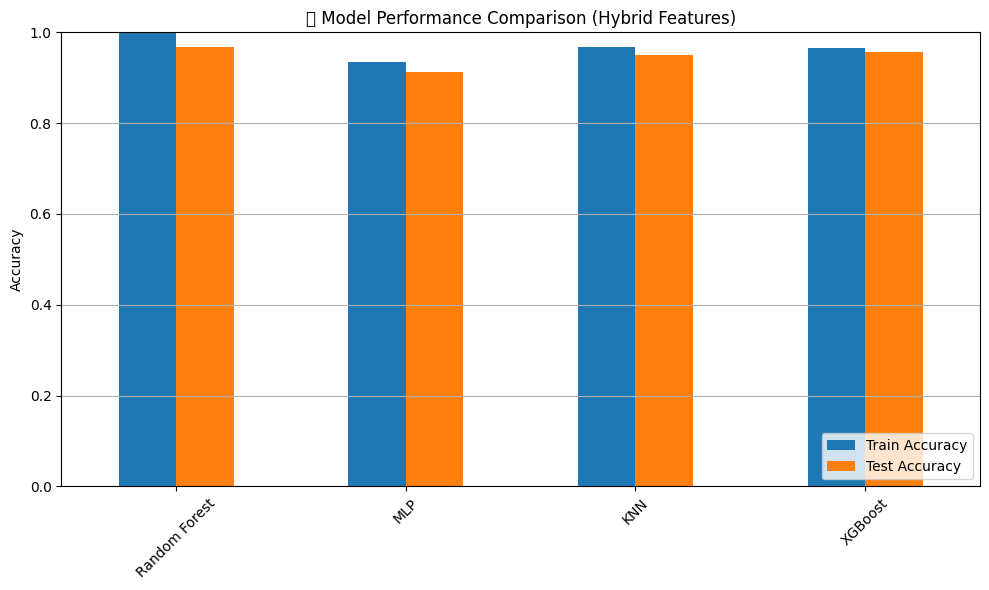

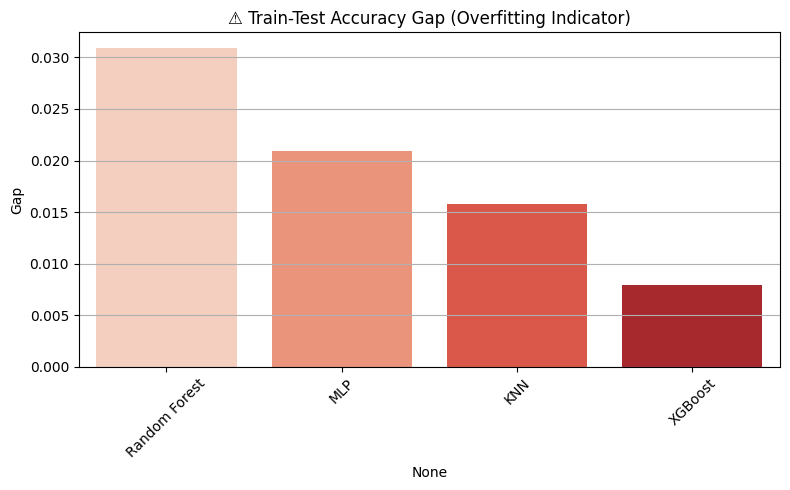

In [13]:
# Step 1: Use only top 20 features from MI
# Ensure X_train_bal and y_train_bal are not empty
if X_train_bal.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
    mi_scores = mutual_info_classif(X_train_bal, y_train_bal, random_state=42)
    mi_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)
    top_k_mi = 20  # Reduced for speed
    top_features = mi_series.head(top_k_mi).index.tolist()

    X_train_mi = X_train_bal[top_features]
    X_test_mi = X_test[top_features]

    # Step 2: Genetic Algorithm Setup
    K = 11  # Desired selected features from 20

    if not hasattr(creator, "FitnessMax"):
        creator.create("FitnessMax", base.Fitness, weights=(1.0,))
    if not hasattr(creator, "Individual"):
        creator.create("Individual", list, fitness=creator.FitnessMax)

    toolbox = base.Toolbox()
    toolbox.register("attr_bool", random.randint, 0, 1)
    toolbox.register("individual", tools.initRepeat, creator.Individual, toolbox.attr_bool, n=top_k_mi)
    toolbox.register("population", tools.initRepeat, list, toolbox.individual)

    def get_fitness(individual):
        if sum(individual) == 0:
            return 0.,

        idx = [i for i, bit in enumerate(individual) if bit == 1]
        X_sub = X_train_mi.iloc[:, idx]

        clf = DecisionTreeClassifier(max_depth=6, random_state=42)  # Shallower DT for speed
        # Check if there are enough samples and classes for cross_val_score
        if X_sub.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
            scores = cross_val_score(clf, X_sub, y_train_bal, cv=2, scoring='accuracy')  # Faster CV
            acc = scores.mean()
        else:
            acc = 0.0 # Return 0 accuracy if data is insufficient

        penalty = 0.01 * (sum(individual) - K) ** 2
        return acc - penalty,

    toolbox.register("evaluate", get_fitness)
    toolbox.register("mate", tools.cxTwoPoint)
    toolbox.register("mutate", tools.mutFlipBit, indpb=0.1)
    toolbox.register("select", tools.selTournament, tournsize=2)

    pop = toolbox.population(n=15)  # Smaller population
    hof = tools.HallOfFame(1)

    start = time.time()
    print("⏳ Running Optimized Genetic Algorithm...")
    algorithms.eaSimple(pop, toolbox, cxpb=0.5, mutpb=0.3, ngen=6, halloffame=hof, verbose=False)  # Fewer generations
    end = time.time()
    print(f"✅ GA completed in {(end - start):.2f} seconds")

    # Selected Features
    selected_idx = [i for i, bit in enumerate(hof[0]) if bit == 1]
    selected_features = [top_features[i] for i in selected_idx]
    print(f"✅ GA Selected {len(selected_features)} Features:\n{selected_features}")

    # Final selected feature dataset
    X_train_sel = X_train_bal[selected_features]
    X_test_sel = X_test[selected_features]

    from sklearn.preprocessing import StandardScaler

    scaler = StandardScaler()
    X_train_sel_scaled = scaler.fit_transform(X_train_sel)
    X_test_sel_scaled = scaler.transform(X_test_sel)


    from sklearn.metrics import accuracy_score, classification_report

    hybrid_results = {}
    print("\n📊 Classification Report (Hybrid Selected Features):\n")

    for name, model in models.items():
        if name == "MLP":
            model.fit(X_train_sel_scaled, y_train_bal)
            y_train_pred = model.predict(X_train_sel_scaled)
            y_test_pred = model.predict(X_test_sel_scaled)
        else:
            model.fit(X_train_sel, y_train_bal)
            y_train_pred = model.predict(X_train_sel)
            y_test_pred = model.predict(X_test_sel)

        # model.fit(X_train_sel, y_train_bal)

        # y_train_pred = model.predict(X_train_sel)
        # y_test_pred = model.predict(X_test_sel)

        train_acc = accuracy_score(y_train_bal, y_train_pred)
        test_acc = accuracy_score(y_test, y_test_pred)

        hybrid_results[name] = {
            "Train Accuracy": train_acc,
            "Test Accuracy": test_acc,
            "Classification Report": classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_], output_dict=True)
        }

        print(f"\n🧠 Model: {name}")
        print(f"🔹 Train Accuracy: {train_acc:.4f}")
        print(f"🔹 Test Accuracy : {test_acc:.4f}")
        print("🔸 Classification Report (Test):")
        print(classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_]))

    # Create Overfitting Gap Table
    overfit_df = pd.DataFrame({
        model: {
            "Train Accuracy": vals["Train Accuracy"],
            "Test Accuracy": vals["Test Accuracy"],
            "Gap": vals["Train Accuracy"] - vals["Test Accuracy"]
        }
        for model, vals in hybrid_results.items()
    }).T

    print("\n📉 Overfitting Check (Train-Test Accuracy Gap):")
    display(overfit_df.sort_values(by="Gap", ascending=False))

    import matplotlib.pyplot as plt
    import seaborn as sns

    # Barplot of Train/Test Accuracy
    plt.figure(figsize=(10,6))
    overfit_df[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(10,6))
    plt.title("🔍 Model Performance Comparison (Hybrid Features)")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    # Gap Visualization
    plt.figure(figsize=(8,5))
    sns.barplot(x=overfit_df.index, y=overfit_df['Gap'], palette="Reds")
    plt.title("⚠️ Train-Test Accuracy Gap (Overfitting Indicator)")
    plt.ylabel("Gap")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
else:
    print("❗ Skipping feature selection and model training due to insufficient data or classes after filtering minority classes.")

⏳ Running Pure Genetic Algorithm for Feature Selection...
✅ Pure GA completed in 678.35 seconds
✅ Pure GA Selected 19 Features:
['Fwd_Pkt_Len_Std', 'Bwd_Pkt_Len_Max', 'Flow_IAT_Mean', 'Bwd_IAT_Std', 'Bwd_PSH_Flags', 'Fwd_URG_Flags', 'SYN_Flag_Cnt', 'RST_Flag_Cnt', 'Down/Up_Ratio', 'Pkt_Size_Avg', 'Bwd_Byts/b_Avg', 'Subflow_Bwd_Pkts', 'Subflow_Bwd_Byts', 'Init_Fwd_Win_Byts', 'Fwd_Act_Data_Pkts', 'Fwd_Seg_Size_Min', 'Active_Max', 'Idle_Mean', 'Idle_Min']

📊 Classification Report (Pure GA Selected Features):


🧠 Model: Random Forest
🔹 Train Accuracy: 0.9103
🔹 Test Accuracy : 0.8158
🔸 Classification Report (Test):
                   precision    recall  f1-score   support

              DoS       1.00      1.00      1.00     11872
MITM ARP Spoofing       0.29      0.52      0.37      3009
            Mirai       0.94      0.79      0.86     28667
           Normal       0.93      0.90      0.92      5506
             Scan       0.30      0.54      0.39      3255

         accuracy         

,Train Accuracy,Test Accuracy,Gap
Random Forest,0.910291,0.815806,0.094485
XGBoost,0.827998,0.812824,0.015174
MLP,0.798149,0.794452,0.003697
KNN,0.798177,0.846871,-0.048694


<Figure size 1000x600 with 0 Axes>

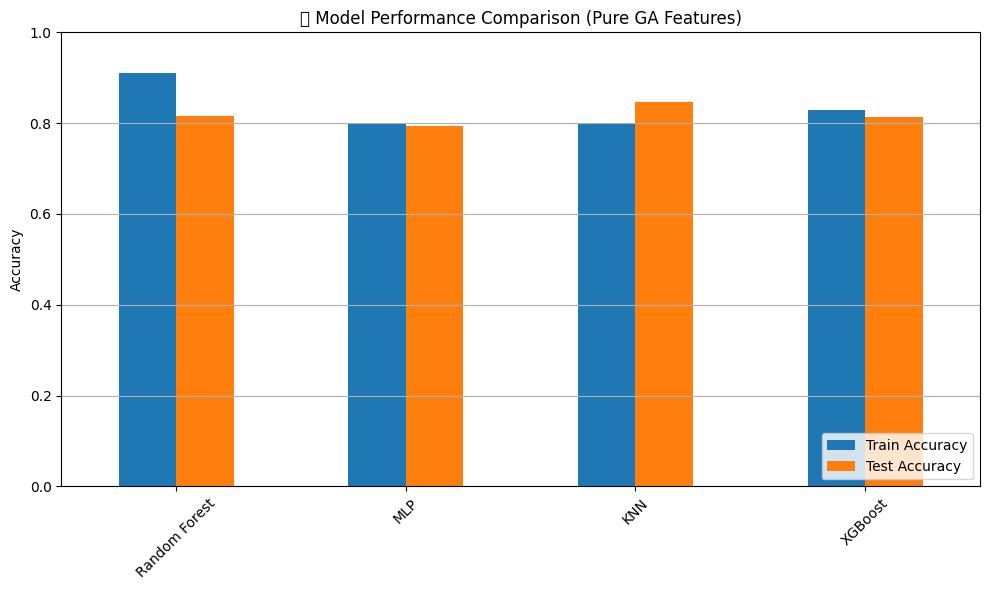

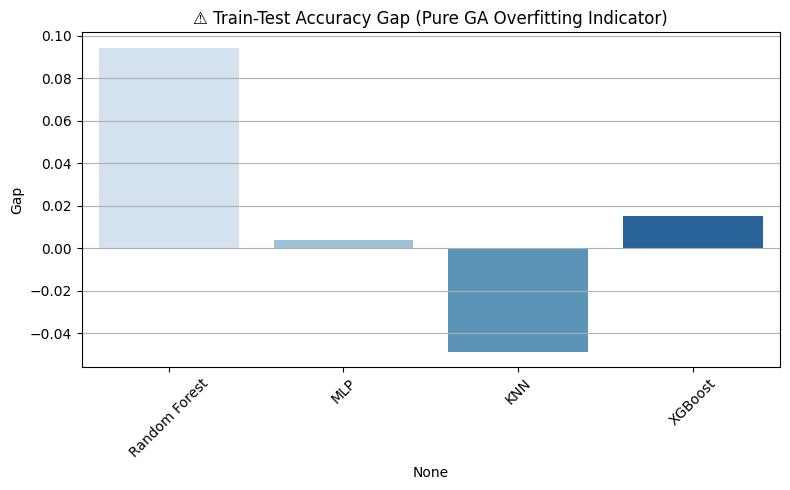

In [14]:
#individual GE algo
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from deap import base, creator, tools, algorithms
import random
import time
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier

# Ensure creator classes are not redefined if the cell is run multiple times
# Use unique names for the pure GA setup
try:
    del creator.FitnessMax_PureGA
    del creator.Individual_PureGA
except AttributeError:
    pass

# --- Step 1: Define the full set of features for the GA to choose from ---
# In a pure GA approach, we start with all available features
all_features = X.columns # X is the original feature set before splitting
N_FEATURES = len(all_features) # Total number of features

# --- Step 2: Genetic Algorithm Setup (Pure GA) ---

# This K now represents the desired number of features from the *entire* dataset
K = 11 # You can adjust this desired number of features

# Define fitness and individual types for DEAP
# Using unique names to avoid conflicts if the previous GA cell was also run
creator.create("FitnessMax_PureGA", base.Fitness, weights=(1.0,))
creator.create("Individual_PureGA", list, fitness=creator.FitnessMax_PureGA)

toolbox_pure_ga = base.Toolbox()
toolbox_pure_ga.register("attr_bool", random.randint, 0, 1)
# Individual length is now N_FEATURES, representing all available features
toolbox_pure_ga.register("individual", tools.initRepeat, creator.Individual_PureGA, toolbox_pure_ga.attr_bool, n=N_FEATURES)
toolbox_pure_ga.register("population", tools.initRepeat, list, toolbox_pure_ga.individual)

def get_fitness_pure_ga(individual):
    if sum(individual) == 0: # If no features are selected
        return 0.,

    idx = [i for i, bit in enumerate(individual) if bit == 1]
    # Use the full balanced training data, selecting columns based on 'idx'
    X_sub = X_train_bal.iloc[:, idx]

    clf = DecisionTreeClassifier(max_depth=6, random_state=42) # Shallower DT for speed
    # Check if there are enough samples and classes for cross_val_score
    if X_sub.shape[0] > 0 and len(np.unique(y_train_bal)) > 1:
        scores = cross_val_score(clf, X_sub, y_train_bal, cv=2, scoring='accuracy') # Faster CV
        acc = scores.mean()
    else:
        acc = 0.0 # Return 0 accuracy if data is insufficient

    penalty = 0.01 * (sum(individual) - K) ** 2 # Penalty for deviating from K features
    return acc - penalty,

toolbox_pure_ga.register("evaluate", get_fitness_pure_ga)
toolbox_pure_ga.register("mate", tools.cxTwoPoint)
toolbox_pure_ga.register("mutate", tools.mutFlipBit, indpb=0.1) # Probability of a bit flipping
toolbox_pure_ga.register("select", tools.selTournament, tournsize=2) # Tournament selection

pop_pure_ga = toolbox_pure_ga.population(n=15) # Initial population size
hof_pure_ga = tools.HallOfFame(1) # To store the best individual found

start = time.time()
print("⏳ Running Pure Genetic Algorithm for Feature Selection...")
# More generations might be needed for a larger feature space, adjust ngen if necessary
algorithms.eaSimple(pop_pure_ga, toolbox_pure_ga, cxpb=0.5, mutpb=0.3, ngen=10, halloffame=hof_pure_ga, verbose=False)
end = time.time()
print(f"✅ Pure GA completed in {(end - start):.2f} seconds")

# Selected Features
selected_idx_pure_ga = [i for i, bit in enumerate(hof_pure_ga[0]) if bit == 1]
# Map selected indices back to original feature names
selected_features_pure_ga = all_features[selected_idx_pure_ga].tolist()
print(f"✅ Pure GA Selected {len(selected_features_pure_ga)} Features:\n{selected_features_pure_ga}")

# Final selected feature dataset
X_train_sel_pure_ga = X_train_bal[selected_features_pure_ga]
X_test_sel_pure_ga = X_test[selected_features_pure_ga]

# Scale features for models that require it (e.g., MLP, KNN)
scaler_pure_ga = StandardScaler()
X_train_sel_scaled_pure_ga = scaler_pure_ga.fit_transform(X_train_sel_pure_ga)
X_test_sel_scaled_pure_ga = scaler_pure_ga.transform(X_test_sel_pure_ga)

# Re-define models here for clarity or use the existing 'models' dict
# (Assuming 'models' dict and 'le' (LabelEncoder) from previous cells are accessible)
models_pure_ga = {
    'Random Forest': RandomForestClassifier(random_state=42),
    "MLP": MLPClassifier(hidden_layer_sizes=(64, 32), activation='relu', solver='adam', max_iter=300, random_state=42, early_stopping=True),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss'),
}

pure_ga_results = {}
print("\n📊 Classification Report (Pure GA Selected Features):\n")

for name, model in models_pure_ga.items():
    if name == "MLP":
        model.fit(X_train_sel_scaled_pure_ga, y_train_bal)
        y_train_pred = model.predict(X_train_sel_scaled_pure_ga)
        y_test_pred = model.predict(X_test_sel_scaled_pure_ga)
    else:
        model.fit(X_train_sel_pure_ga, y_train_bal)
        y_train_pred = model.predict(X_train_sel_pure_ga)
        y_test_pred = model.predict(X_test_sel_pure_ga)

    train_acc = accuracy_score(y_train_bal, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    pure_ga_results[name] = {
        "Train Accuracy": train_acc,
        "Test Accuracy": test_acc,
        "Classification Report": classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_], output_dict=True)
    }

    print(f"\n🧠 Model: {name}")
    print(f"🔹 Train Accuracy: {train_acc:.4f}")
    print(f"🔹 Test Accuracy : {test_acc:.4f}")
    print("🔸 Classification Report (Test):")
    print(classification_report(y_test, y_test_pred, target_names=[str(c) for c in le.classes_]))

# Create Overfitting Gap Table
overfit_df_pure_ga = pd.DataFrame({
    model: {
        "Train Accuracy": vals["Train Accuracy"],
        "Test Accuracy": vals["Test Accuracy"],
        "Gap": vals["Train Accuracy"] - vals["Test Accuracy"]
    }
    for model, vals in pure_ga_results.items()
}).T

print("\n📉 Overfitting Check (Train-Test Accuracy Gap for Pure GA):")
display(overfit_df_pure_ga.sort_values(by="Gap", ascending=False))

import matplotlib.pyplot as plt
import seaborn as sns

# Barplot of Train/Test Accuracy
plt.figure(figsize=(10,6))
overfit_df_pure_ga[['Train Accuracy', 'Test Accuracy']].plot(kind='bar', figsize=(10,6))
plt.title("🔍 Model Performance Comparison (Pure GA Features)")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Gap Visualization
plt.figure(figsize=(8,5))
sns.barplot(x=overfit_df_pure_ga.index, y=overfit_df_pure_ga['Gap'], palette="Blues")
plt.title("⚠️ Train-Test Accuracy Gap (Pure GA Overfitting Indicator)")
plt.ylabel("Gap")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()